# 🛒 E-Commerce Sales Analysis

**Author:** Gaurav Bisen
**Tools:** Python (Pandas, NumPy, Matplotlib), Faker, SQL (MySQL)

## Project Overview
Online retailers generate huge volumes of transactional data every day. This project simulates a
realistic e-commerce dataset (customers, products, orders, and order line items) and analyzes it to
answer key business questions such as:

- Who are the top revenue-generating customers and products?
- Which product categories perform best?
- How does revenue trend over time?
- What share of orders are cancelled, returned, or have failed payments?

## Workflow
1. Generate a realistic synthetic dataset using the `Faker` library
2. Clean and merge the data into a single analysis-ready table
3. Compute key business metrics (KPIs)
4. Visualize trends and rankings with Matplotlib
5. Summarize insights and recommendations

---

## 1. Setup & Imports
Install and import the libraries used throughout this notebook.

In [1]:
# Uncomment the line below if running for the first time / in a fresh environment
# %pip install faker pandas numpy matplotlib

from faker import Faker
import pandas as pd
import numpy as np
import random
import os
import matplotlib.pyplot as plt

fake = Faker("en_IN")
random.seed(42)  # for reproducible results

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Generate Customer Data
We simulate 1,000 customers with realistic Indian names, contact details, and signup dates using `Faker`.

In [2]:
num_customers = 1000

customers = []

for customer_id in range(1, num_customers + 1):
    customers.append({
        "customer_id": customer_id,
        "customer_name": fake.name(),
        "email": fake.unique.email(),
        "phone": fake.phone_number(),
        "city": fake.city(),
        "state": fake.state(),
        "signup_date": fake.date_between(start_date="-3y", end_date="today")
    })

df_customers = pd.DataFrame(customers)
print("Customer data generated successfully!")
df_customers.head()

Customer data generated successfully!


,customer_id,customer_name,email,phone,city,state,signup_date
0,1,Anjali Bajaj,sarmasaanvi@example.net,8428360324,Avadi,Uttarakhand,2026-05-03
1,2,Gayathri Barad,sundaramganga@example.org,+915409394336,Mangalore,Sikkim,2026-01-24
2,3,Eiravati Dass,chaitalyrau@example.org,9188567029,Tenali,Arunachal Pradesh,2026-01-21
3,4,Advay Jani,daveanika@example.com,+917326087511,Chittoor,Nagaland,2025-05-31
4,5,Tanvi Edwin,qkarnik@example.com,08425638562,Vadodara,Telangana,2024-07-13


In [3]:
os.makedirs("dataset", exist_ok=True)
df_customers.to_csv("dataset/customers.csv", index=False)

print(f"Shape: {df_customers.shape}")
df_customers.info()

Shape: (1000, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customer_id    1000 non-null   int64 
 1   customer_name  1000 non-null   str   
 2   email          1000 non-null   str   
 3   phone          1000 non-null   str   
 4   city           1000 non-null   str   
 5   state          1000 non-null   str   
 6   signup_date    1000 non-null   object
dtypes: int64(1), object(1), str(5)
memory usage: 54.8+ KB


## 3. Generate Product Catalog
1,000 products are generated across 6 categories, each with a price, stock quantity, and average rating.

In [4]:
categories = [
    "Electronics",
    "Clothing",
    "Home & Kitchen",
    "Books",
    "Sports",
    "Beauty"
]

product_names = [
    "Laptop",
    "Mobile Phone",
    "Headphones",
    "T-Shirt",
    "Shoes",
    "Mixer",
    "Book",
    "Cricket Bat",
    "Face Cream",
    "Smart Watch"
]

products = []

for product_id in range(1, 1001):
    product_name = random.choice(product_names)
    category = random.choice(categories)
    price = random.randint(200, 80000)
    stock_quantity = random.randint(10, 500)
    rating = round(random.uniform(1, 5), 1)

    products.append([
        product_id,
        product_name,
        category,
        price,
        stock_quantity,
        rating
    ])

df_products = pd.DataFrame(
    products,
    columns=[
        "product_id",
        "product_name",
        "category",
        "price",
        "stock_quantity",
        "rating"
    ]
)

df_products.head()

,product_id,product_name,category,price,stock_quantity,rating
0,1,Mobile Phone,Electronics,36248,135,1.9
1,2,Mobile Phone,Beauty,71682,54,3.4
2,3,Laptop,Electronics,12480,121,1.9
3,4,Smart Watch,Electronics,73763,111,3.9
4,5,Face Cream,Books,29093,239,3.4


In [5]:
df_products.to_csv("dataset/products.csv", index=False)

print(f"Shape: {df_products.shape}")
df_products.info()

Shape: (1000, 6)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      1000 non-null   int64  
 1   product_name    1000 non-null   str    
 2   category        1000 non-null   str    
 3   price           1000 non-null   int64  
 4   stock_quantity  1000 non-null   int64  
 5   rating          1000 non-null   float64
dtypes: float64(1), int64(3), str(2)
memory usage: 47.0 KB


## 4. Generate Orders
10,000 orders are generated over the last 2 years, each linked to a random customer with an order
status and payment status.

In [6]:
orders = []

for order_id in range(1, 10001):
    customer_id = random.randint(1, 1000)
    order_date = fake.date_between(start_date="-2y", end_date="today")
    order_status = random.choice([
        "Pending", "Confirmed", "Shipped", "Delivered", "Cancelled", "Returned"
    ])
    total_amount = random.randint(500, 50000)
    payment_status = random.choice([
        "Pending", "Paid", "Failed", "Refunded"
    ])

    orders.append([
        order_id, customer_id, order_date, order_status, total_amount, payment_status
    ])

df_orders = pd.DataFrame(
    orders,
    columns=[
        "order_id", "customer_id", "order_date",
        "order_status", "total_amount", "payment_status"
    ]
)

df_orders.head()

,order_id,customer_id,order_date,order_status,total_amount,payment_status
0,1,374,2026-02-21,Shipped,28569,Paid
1,2,5,2025-02-04,Shipped,16633,Paid
2,3,730,2025-05-30,Returned,42497,Refunded
3,4,284,2026-07-12,Shipped,9301,Failed
4,5,899,2025-01-12,Delivered,30833,Refunded


In [7]:
df_orders.to_csv("dataset/orders.csv", index=False)

print(f"Shape: {df_orders.shape}")
df_orders.describe()

Shape: (10000, 6)


,order_id,customer_id,total_amount
count,10000.00000,10000.000000,10000.000000
mean,5000.50000,500.446700,25451.205100
std,2886.89568,289.793958,14305.503944
min,1.00000,1.000000,502.000000
25%,2500.75000,249.000000,12978.750000
50%,5000.50000,497.000000,25487.000000
75%,7500.25000,754.000000,38071.250000
max,10000.00000,1000.000000,49995.000000


## 5. Generate Order Line Items (Order Details)
Each order can contain multiple products. We generate 20,000 order line items, apply a random
discount, and compute the final sales amount for each line.

In [8]:
order_details = []

for detail_id in range(1, 20001):
    order_id = random.randint(1, 10000)
    product_id = random.randint(1, 1000)
    quantity = random.randint(1, 5)

    price = df_products.loc[
        df_products["product_id"] == product_id, "price"
    ].values[0]

    discount = random.randint(0, 30)
    final_amount = quantity * price * (1 - discount / 100)

    order_details.append([
        detail_id, order_id, product_id, quantity, discount, round(final_amount, 2)
    ])

df_order_details = pd.DataFrame(
    order_details,
    columns=[
        "detail_id", "order_id", "product_id", "quantity", "discount", "sales_amount"
    ]
)

df_order_details.head()

,detail_id,order_id,product_id,quantity,discount,sales_amount
0,1,2654,998,2,1,74394.54
1,2,7078,750,3,25,55642.50
2,3,9527,910,3,21,120031.02
3,4,432,28,2,26,66284.76
4,5,8726,98,5,25,212741.25


In [9]:
df_order_details.to_csv("dataset/order_details.csv", index=False)

print(f"Shape: {df_order_details.shape}")
df_order_details.info()

Shape: (20000, 6)
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   detail_id     20000 non-null  int64  
 1   order_id      20000 non-null  int64  
 2   product_id    20000 non-null  int64  
 3   quantity      20000 non-null  int64  
 4   discount      20000 non-null  int64  
 5   sales_amount  20000 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 937.6 KB


## 6. Build the Master Sales Table
We merge `order_details` with `orders` and `products` to create a single analysis-ready table
(`sales_df`) that contains customer, order, and product information for every line item.

In [10]:
sales_df = df_order_details.merge(df_orders, on="order_id", how="left")
sales_df = sales_df.merge(df_products, on="product_id", how="left")

print(f"Shape: {sales_df.shape}")
sales_df.head()

Shape: (20000, 16)


,detail_id,order_id,product_id,quantity,discount,sales_amount,customer_id,order_date,order_status,total_amount,payment_status,product_name,category,price,stock_quantity,rating
0,1,2654,998,2,1,74394.54,8,2025-10-14,Returned,2618,Refunded,T-Shirt,Electronics,37573,327,1.3
1,2,7078,750,3,25,55642.50,841,2025-09-02,Pending,42049,Pending,Mixer,Clothing,24730,150,2.1
2,3,9527,910,3,21,120031.02,214,2025-08-22,Confirmed,2187,Pending,Cricket Bat,Home & Kitchen,50646,86,4.4
3,4,432,28,2,26,66284.76,803,2025-06-11,Delivered,49166,Pending,Shoes,Beauty,44787,67,2.2
4,5,8726,98,5,25,212741.25,444,2026-03-07,Cancelled,3219,Failed,T-Shirt,Home & Kitchen,56731,45,4.8


In [11]:
# Quick data quality check
sales_df.isnull().sum()

detail_id         0
order_id          0
product_id        0
quantity          0
discount          0
sales_amount      0
customer_id       0
order_date        0
order_status      0
total_amount      0
payment_status    0
product_name      0
category          0
price             0
stock_quantity    0
rating            0
dtype: int64

## 7. Key Business Metrics (KPIs)
High-level numbers every stakeholder cares about: total revenue, total orders, and total products sold.

In [12]:
total_sales = sales_df["sales_amount"].sum()
total_orders = sales_df["order_id"].nunique()
total_products = sales_df["product_id"].nunique()
average_order_value = sales_df.groupby("order_id")["sales_amount"].sum().mean()
total_quantity = sales_df["quantity"].sum()

print(f"Total Revenue        : ₹{total_sales:,.2f}")
print(f"Total Orders          : {total_orders:,}")
print(f"Total Unique Products : {total_products:,}")
print(f"Average Order Value   : ₹{average_order_value:,.2f}")
print(f"Total Units Sold       : {total_quantity:,}")

Total Revenue        : ₹2,111,574,733.43
Total Orders          : 8,684
Total Unique Products : 1,000
Average Order Value   : ₹243,156.92
Total Units Sold       : 60,115


## 8. Top 10 Products by Revenue

In [13]:
top_products = (
    sales_df.groupby("product_name")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products

product_name
Mixer           2.733803e+08
Headphones      2.429333e+08
Face Cream      2.199294e+08
Cricket Bat     2.109010e+08
Smart Watch     2.072869e+08
Shoes           2.062482e+08
Book            2.036663e+08
T-Shirt         1.929295e+08
Mobile Phone    1.901131e+08
Laptop          1.641867e+08
Name: sales_amount, dtype: float64

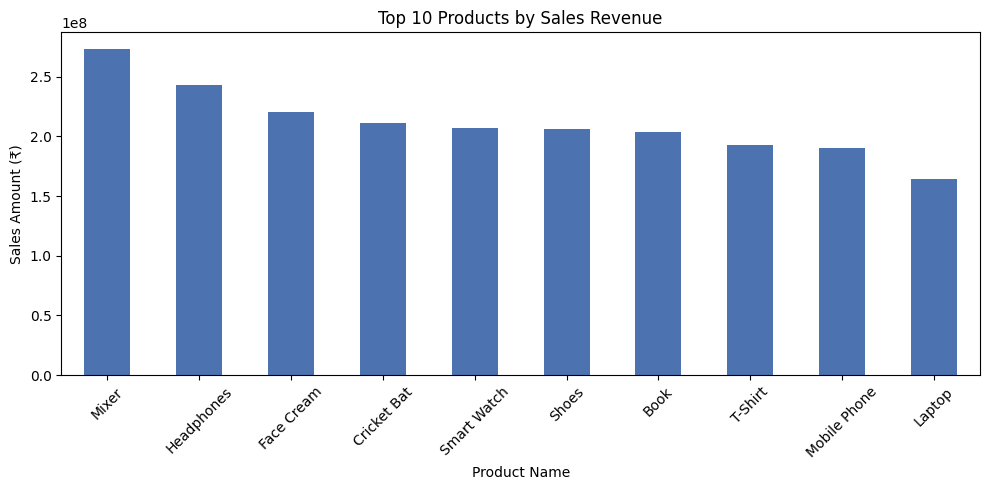

In [14]:
plt.figure(figsize=(10, 5))
top_products.plot(kind="bar", color="#4C72B0")
plt.title("Top 10 Products by Sales Revenue")
plt.xlabel("Product Name")
plt.ylabel("Sales Amount (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/01_top_10_products_sales_revenue.png")
plt.show()

## 9. Revenue by Category

In [15]:
category_sales = (
    sales_df.groupby("category")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
)
category_sales

category
Electronics       3.855977e+08
Sports            3.805669e+08
Books             3.543506e+08
Clothing          3.518418e+08
Beauty            3.245011e+08
Home & Kitchen    3.147167e+08
Name: sales_amount, dtype: float64

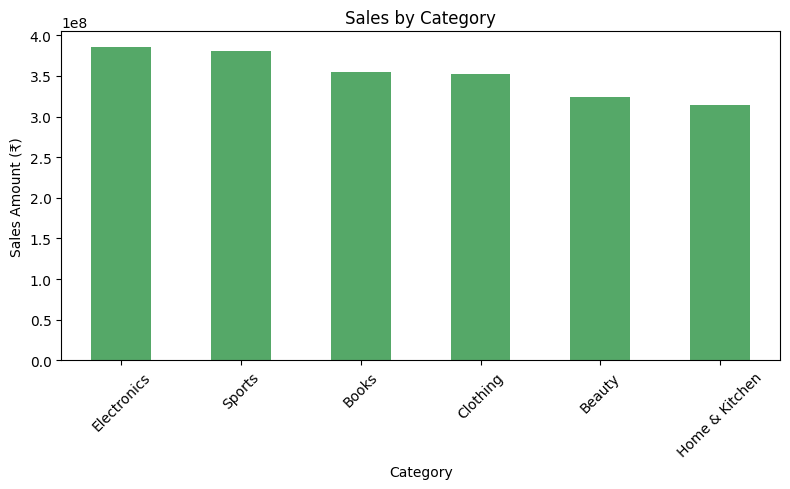

In [16]:
plt.figure(figsize=(8, 5))
category_sales.plot(kind="bar", color="#55A868")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales Amount (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/02_sales_by_category.png")
plt.show()

## 10. Monthly Sales Trend

In [17]:
sales_df["order_date"] = pd.to_datetime(sales_df["order_date"])
sales_df["month"] = sales_df["order_date"].dt.to_period("M")

monthly_sales = sales_df.groupby("month")["sales_amount"].sum()
monthly_sales

month
2024-07    5.057823e+07
2024-08    8.994028e+07
2024-09    8.209774e+07
2024-10    8.547090e+07
2024-11    9.547728e+07
2024-12    9.510195e+07
2025-01    8.421090e+07
2025-02    8.208652e+07
2025-03    9.467029e+07
2025-04    7.710035e+07
2025-05    1.024333e+08
2025-06    7.879318e+07
2025-07    8.525779e+07
2025-08    9.298474e+07
2025-09    8.614961e+07
2025-10    8.901204e+07
2025-11    8.406571e+07
2025-12    8.258549e+07
2026-01    9.418134e+07
2026-02    8.993806e+07
2026-03    8.407586e+07
2026-04    9.038551e+07
2026-05    8.949509e+07
2026-06    8.312716e+07
2026-07    4.235540e+07
Freq: M, Name: sales_amount, dtype: float64

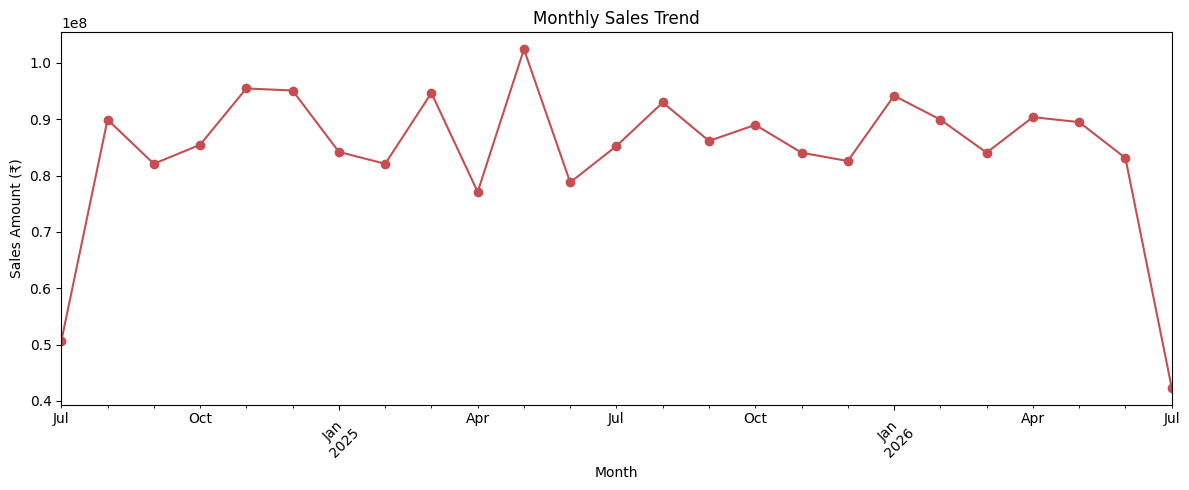

In [18]:
plt.figure(figsize=(12, 5))
monthly_sales.plot(kind="line", marker="o", color="#C44E52")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/03_monthly_sales_trend.png")
plt.show()

## 11. Order Status Distribution

In [19]:
order_status_count = sales_df["order_status"].value_counts()
order_status_count

order_status
Returned     3480
Delivered    3409
Confirmed    3346
Cancelled    3313
Pending      3271
Shipped      3181
Name: count, dtype: int64

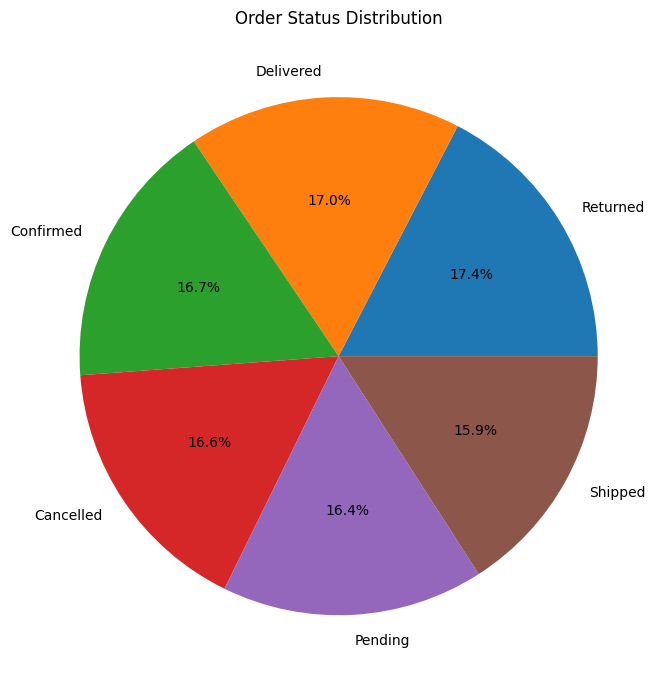

In [20]:
plt.figure(figsize=(7, 7))
order_status_count.plot(kind="pie", autopct="%1.1f%%")
plt.title("Order Status Distribution")
plt.ylabel("")
plt.tight_layout()
plt.savefig("images/04_order_status_distribution.png")
plt.show()

## 12. Payment Status Analysis

In [21]:
payment_analysis = sales_df["payment_status"].value_counts()
payment_analysis

payment_status
Paid        5122
Refunded    5119
Pending     5053
Failed      4706
Name: count, dtype: int64

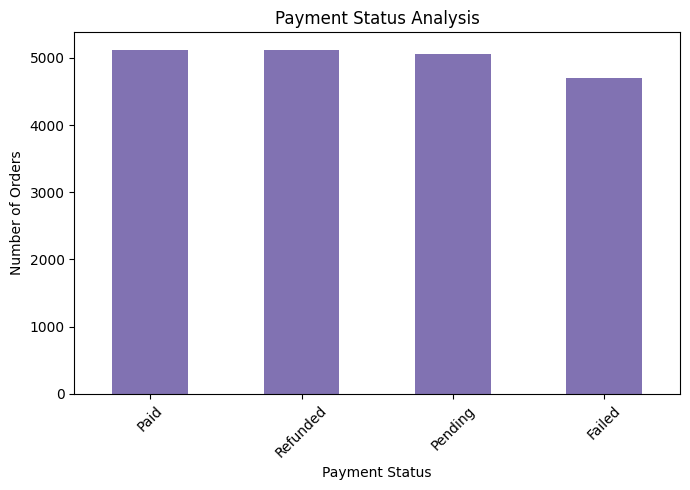

In [22]:
plt.figure(figsize=(7, 5))
payment_analysis.plot(kind="bar", color="#8172B2")
plt.title("Payment Status Analysis")
plt.xlabel("Payment Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/05_payment_status_analysis.png")
plt.show()

## 13. Top 10 Customers by Revenue

In [23]:
top_customers = (
    sales_df.groupby("customer_id")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_customers

customer_id
855    5936058.19
331    5394413.38
992    5354885.37
248    5195834.98
262    5119460.43
881    5015792.54
905    4953916.60
622    4934252.32
147    4881533.94
946    4792305.36
Name: sales_amount, dtype: float64

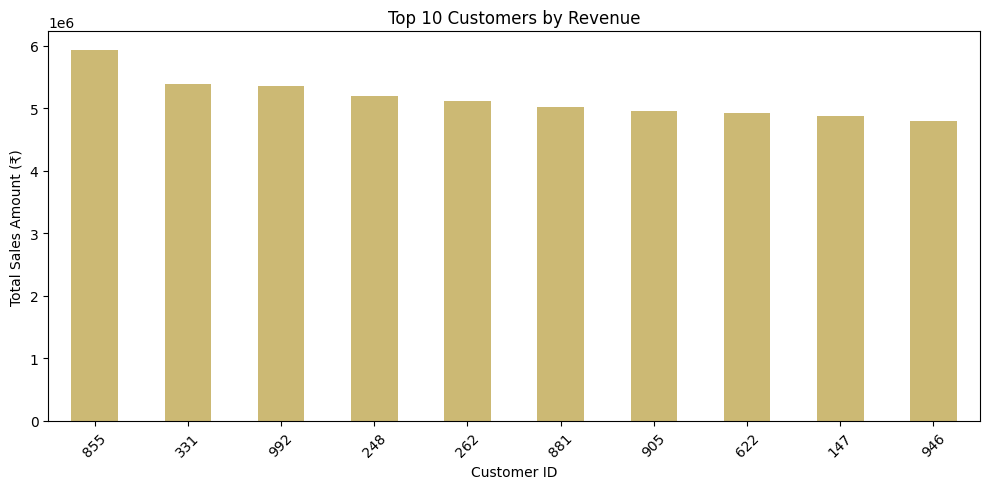

In [24]:
plt.figure(figsize=(10, 5))
top_customers.plot(kind="bar", color="#CCB974")
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Sales Amount (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("images/06_top_customers_revenue.png")
plt.show()

## 14. Most Popular Category by Units Sold

In [25]:
popular_category = (
    sales_df.groupby("category")["quantity"]
    .sum()
    .sort_values(ascending=False)
)
popular_category

category
Electronics       11042
Books             10275
Sports            10062
Clothing          10058
Beauty             9473
Home & Kitchen     9205
Name: quantity, dtype: int64

## 15. Key Insights & Recommendations

- **Revenue concentration:** A small set of top 10 products and top 10 customers contribute a
  disproportionately large share of total revenue — worth targeting for loyalty programs and
  focused inventory planning.
- **Category performance:** Sales are not evenly distributed across categories; the leading
  categories (see Section 9) should be prioritized for marketing spend and stock allocation.
- **Seasonality:** The monthly trend (Section 10) highlights peak and low sales periods that can
  inform promotional calendars and staffing/inventory decisions.
- **Order fulfilment health:** The share of `Cancelled` and `Returned` orders (Section 11) is a
  direct signal of fulfilment or product-quality issues that impact net revenue.
- **Payment friction:** Any meaningful share of `Failed` or `Pending` payments (Section 12)
  represents recoverable revenue — a candidate for retry logic or improved checkout UX.

## Next Steps
- Move this analysis into a MySQL database (see `sql/ecommerce_analysis_queries.sql`) to
  demonstrate SQL-based reporting alongside the Python/Pandas workflow.
- Build an interactive dashboard (Power BI / Tableau / Streamlit) on top of `sales_df`.
- Add cohort and customer lifetime value (CLV) analysis for deeper customer insights.

---
*Dataset is synthetically generated using the `Faker` library for demonstration and portfolio
purposes; it does not represent real transactions or customers.*